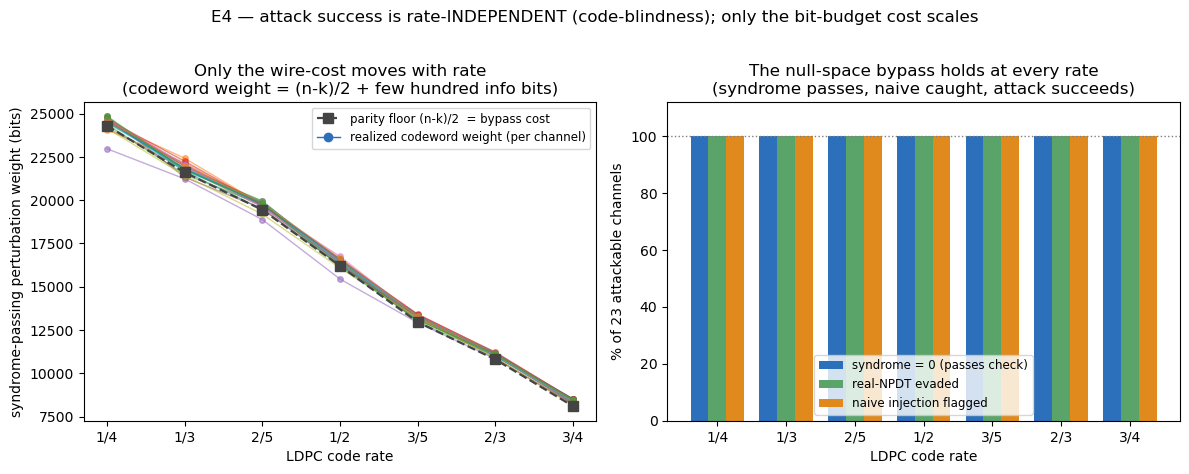

In [2]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

E4 = json.load(open(Path("runs_e4/e4_summary.json")))
rates = [p["rate"] for p in E4[0]["per_rate"]]
x = np.arange(len(rates))
floor = np.array([p["parity_floor"] for p in E4[0]["per_rate"]])
wt = np.array([[p["delta_total_weight_med"] for p in d["per_rate"]] for d in E4])  # chan x rate
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
axL.plot(x, floor, "s--", color="#444", lw=1.6, ms=7, label="parity floor (n-k)/2  = bypass cost", zorder=3)
for row, d in zip(wt, E4):
    axL.plot(x, row, "o-", lw=1, ms=4, alpha=0.55)
axL.plot([], [], "o-", color="#2c6fbb", lw=1, label="realized codeword weight (per channel)")
axL.set_xticks(x); axL.set_xticklabels(rates)
axL.set_xlabel("LDPC code rate"); axL.set_ylabel("syndrome-passing perturbation weight (bits)")
axL.set_title("Only the wire-cost moves with rate\n(codeword weight = (n-k)/2 + few hundred info bits)")
axL.legend(fontsize=8.5, loc="upper right")
n = len(E4)
synd = [100*np.mean([p["frac_frames_syndrome0"]==1.0 for p in d["per_rate"]]) for d in E4]
def frac(metric):
    return [100*np.mean([d["per_rate"][i][metric] == (0.0 if metric=="" else d["per_rate"][i][metric]) for d in E4]) for i in range(len(rates))]
syndrome0 = [100*np.mean([d["per_rate"][i]["frac_frames_syndrome0"]==1.0 for d in E4]) for i in range(len(rates))]
naiveflag = [100*np.mean([d["per_rate"][i]["frac_frames_naive_flagged"]==1.0 for d in E4]) for i in range(len(rates))]
verdict   = [100*np.mean([d["per_rate"][i]["real_npdt_missed"] for d in E4]) for i in range(len(rates))]
w = 0.26
axR.bar(x-w, syndrome0, w, color="#2c6fbb", label="syndrome = 0 (passes check)")
axR.bar(x,   verdict,   w, color="#5aa469", label="real-NPDT evaded")
axR.bar(x+w, naiveflag, w, color="#e08a1e", label="naive injection flagged")
axR.set_xticks(x); axR.set_xticklabels(rates); axR.set_ylim(0, 112)
axR.set_xlabel("LDPC code rate"); axR.set_ylabel(f"% of {n} attackable channels")
axR.axhline(100, color="gray", ls=":", lw=1)
axR.set_title("The null-space bypass holds at every rate\n(syndrome passes, naive caught, attack succeeds)")
axR.legend(fontsize=8.5, loc="lower center")
fig.suptitle("E4 — attack success is rate-INDEPENDENT (code-blindness); only the bit-budget cost scales", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

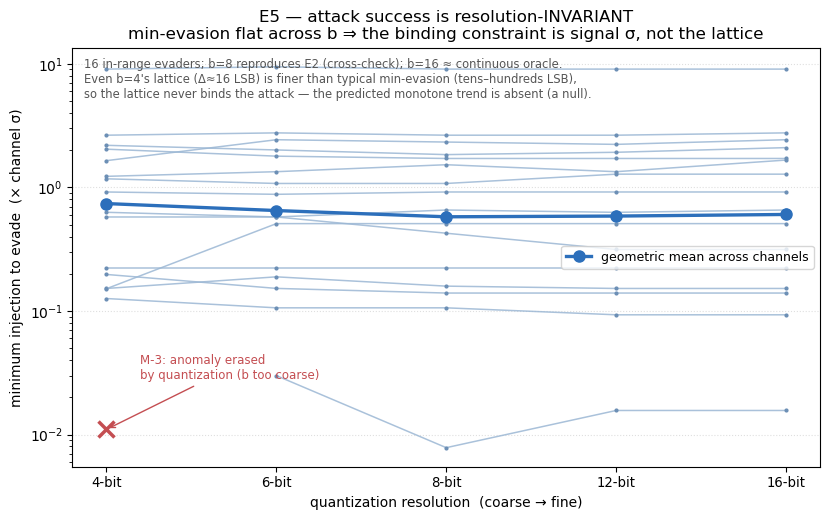

In [4]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
E5 = json.load(open("runs_e5/e5_summary.json"))
B = [4, 6, 8, 12, 16]
xpos = {b: i for i, b in enumerate(B)}
fig, ax = plt.subplots(figsize=(8.4, 5.3))
geom = {b: [] for b in B}
erased = []
for r in E5:
    xs, ys = [], []
    for row in r["by_b"]:
        b = row["b"]
        if not row["clean_hit_at_b"]:
            erased.append((xpos[b], r["chan"])); continue
        v = row["min_evasion_over_sigma"]
        if v is None:
            continue
        xs.append(xpos[b]); ys.append(v); geom[b].append(v)
    ax.plot(xs, ys, "-", color="#9bb7d4", lw=1.1, alpha=0.85, zorder=2)
    ax.plot(xs, ys, ".", color="#6c8fb5", ms=4, zorder=2)
gx = [xpos[b] for b in B if geom[b]]
gy = [float(np.exp(np.mean(np.log(geom[b])))) for b in B if geom[b]]
ax.plot(gx, gy, "o-", color="#2c6fbb", lw=2.4, ms=8, zorder=4, label="geometric mean across channels")
for xv, ch in erased:
    ax.plot(xv, 0.011, "x", color="#c44e52", ms=12, mew=2.5, zorder=5)
    ax.annotate(f"{ch}: anomaly erased\nby quantization (b too coarse)", xy=(xv, 0.011), xytext=(xv + 0.2, 0.028), fontsize=8.5, color="#c44e52", arrowprops=dict(arrowstyle="->", color="#c44e52"))
ax.set_yscale("log")
ax.set_xticks(list(xpos.values()))
ax.set_xticklabels([f"{b}-bit" for b in B], fontsize=9.5)
ax.set_xlabel("quantization resolution  (coarse → fine)")
ax.set_ylabel("minimum injection to evade  (× channel σ)")
ax.set_title("E5 — attack success is resolution-INVARIANT\n"
             "min-evasion flat across b ⇒ the binding constraint is signal σ, not the lattice")
ax.text(0.015, 0.975,
        f"{len(E5)} in-range evaders; b=8 reproduces E2 (cross-check); b=16 ≈ continuous oracle.\n"
        "Even b=4's lattice (Δ≈16 LSB) is finer than typical min-evasion (tens–hundreds LSB),\n"
        "so the lattice never binds the attack — the predicted monotone trend is absent (a null).",
        transform=ax.transAxes, va="top", fontsize=8.3, color="#555")
ax.legend(fontsize=9, loc="center right")
ax.grid(True, axis="y", ls=":", alpha=0.4)
plt.tight_layout(); plt.show()

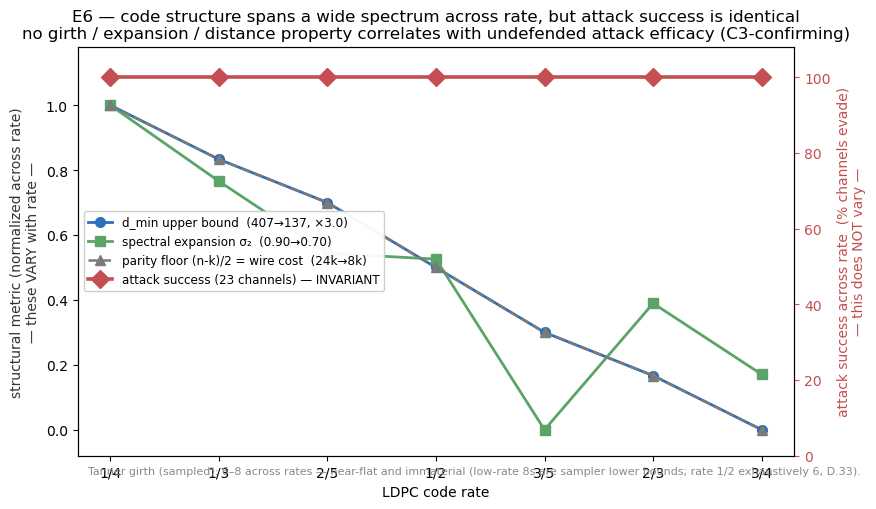

In [6]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
E6 = json.load(open("runs_e6/e6_summary.json"))
sp = E6["spectrum"]
rates = [r["rate"] for r in sp]
x = np.arange(len(rates))
dmin  = np.array([r["dmin_upper_bound"] for r in sp], float)
sig2  = np.array([r["sigma2_expansion"] for r in sp], float)
floor = np.array([r["parity_floor"] for r in sp], float)
n_ch  = E6["e4_invariance"]["n_channels"]
def nrm(v): return (v - v.min()) / (v.max() - v.min())
fig, axL = plt.subplots(figsize=(9, 5.2))
axL.plot(x, nrm(dmin),  "o-", color="#2c6fbb", lw=2,   ms=7, label=f"d_min upper bound  ({int(dmin.max())}→{int(dmin.min())}, ×3.0)")
axL.plot(x, nrm(sig2),  "s-", color="#5aa469", lw=2,   ms=7, label=f"spectral expansion σ₂  ({sig2.max():.2f}→{sig2.min():.2f})")
axL.plot(x, nrm(floor), "^--", color="#7a7a7a", lw=1.8, ms=7, label=f"parity floor (n-k)/2 = wire cost  ({int(floor.max()/1000)}k→{int(floor.min()/1000)}k)")
axL.set_ylabel("structural metric (normalized across rate)\n— these VARY with rate —", color="#333")
axL.set_ylim(-0.08, 1.18)
axL.set_xticks(x); axL.set_xticklabels(rates)
axL.set_xlabel("LDPC code rate")
axR = axL.twinx()
succ = np.full(len(rates), 100.0)
axR.plot(x, succ, "D-", color="#c44e52", lw=2.6, ms=9, zorder=5, label=f"attack success ({n_ch} channels) — INVARIANT")
axR.set_ylabel("attack success across rate  (% channels evade)\n— this does NOT vary —", color="#c44e52")
axR.set_ylim(0, 108)
axR.tick_params(axis="y", colors="#c44e52")
g = [r["girth_sampled"] for r in sp]
axL.text(0.015, -0.045,
         f"Tanner girth (sampled): {min(g)}–{max(g)} across rates — near-flat and immaterial "
         f"(low-rate 8s are sampler lower bounds; rate 1/2 exhaustively 6, D.33).",
         transform=axL.transAxes, fontsize=8, color="#888")
lines = axL.get_lines() + axR.get_lines()
axL.legend(lines, [l.get_label() for l in lines], loc="center left", fontsize=8.6, framealpha=0.95)
axL.set_title("E6 — code structure spans a wide spectrum across rate, but attack success is identical\n"
              "no girth / expansion / distance property correlates with undefended attack efficacy (C3-confirming)")
plt.tight_layout(); plt.show()

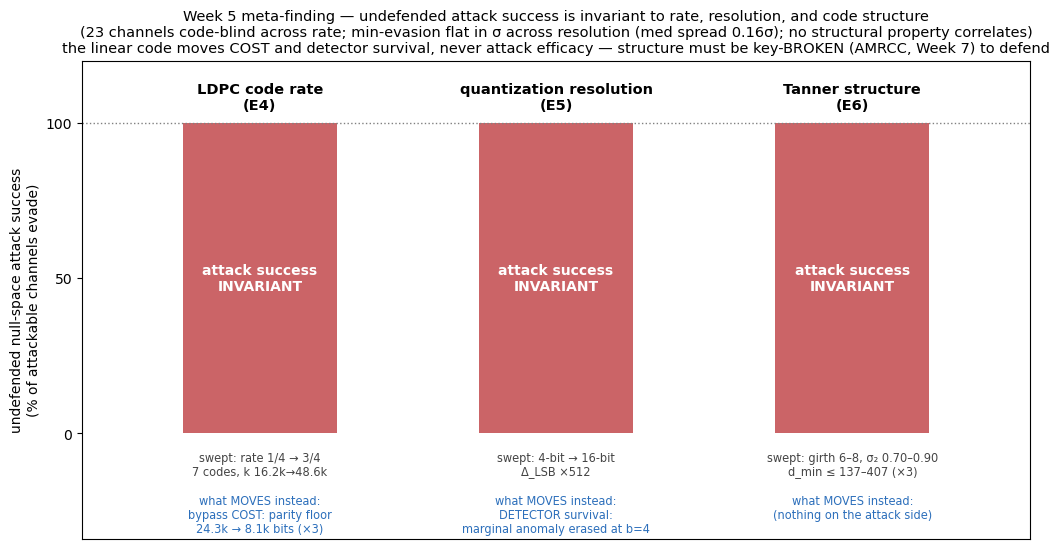

In [8]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

E4 = json.load(open("runs_e4/e4_summary.json"))
E5 = json.load(open("runs_e5/e5_summary.json"))
E6 = json.load(open("runs_e6/e6_summary.json"))

n_e4 = len(E4)
n_e5 = len(E5)
sp = E6["spectrum"]
dmin = [r["dmin_upper_bound"] for r in sp]
floor = [r["parity_floor"] for r in sp]
spreads = []
for r in E5:
    vs = [x["min_evasion_over_sigma"] for x in r["by_b"] if x["min_evasion_over_sigma"] is not None]
    if len(vs) >= 2:
        spreads.append(max(vs) - min(vs))
e5_med_spread = float(np.median(spreads))
fig, ax = plt.subplots(figsize=(10.5, 5.6))
axes_info = [("LDPC code rate\n(E4)", "rate 1/4 → 3/4\n7 codes, k 16.2k→48.6k", "bypass COST: parity floor\n24.3k → 8.1k bits (×3)"), ("quantization resolution\n(E5)", "4-bit → 16-bit\nΔ_LSB ×512", "DETECTOR survival:\nmarginal anomaly erased at b=4"), ("Tanner structure\n(E6)", "girth 6–8, σ₂ 0.70–0.90\nd_min ≤ 137–407 (×3)", "(nothing on the attack side)")]
xc = [0, 1, 2]
for i, (axis, rng, moves) in zip(xc, axes_info):
    ax.bar(i, 100, width=0.52, color="#c44e52", alpha=0.88, zorder=2)
    ax.text(i, 50, "attack success\nINVARIANT", ha="center", va="center", color="white", fontsize=10, fontweight="bold", zorder=3)
    ax.text(i, 103.5, axis, ha="center", va="bottom", fontsize=10.5, fontweight="bold")
    ax.text(i, -6, "swept: " + rng, ha="center", va="top", fontsize=8.2, color="#444")
    ax.text(i, -20, "what MOVES instead:\n" + moves, ha="center", va="top", fontsize=8.2, color="#2c6fbb")
ax.set_xlim(-0.6, 2.6); ax.set_ylim(-34, 120)
ax.set_xticks([]); ax.set_yticks([0, 50, 100])
ax.set_ylabel("undefended null-space attack success\n(% of attackable channels evade)")
ax.axhline(100, color="gray", ls=":", lw=1)
ax.set_title("Week 5 meta-finding — undefended attack success is invariant to rate, resolution, and code structure\n"
             f"({n_e4} channels code-blind across rate; min-evasion flat in σ across resolution (med spread {e5_med_spread:.2f}σ); "
             "no structural property correlates)\n"
             "the linear code moves COST and detector survival, never attack efficacy — structure must be "
             "key-BROKEN (AMRCC, Week 7) to defend",
             fontsize=10.5)
plt.tight_layout(); plt.show()